# Base-use 02 — The ArrowSpace Motives API (`spot_motives_*`, `spot_subg_*`)

**Question.** Beyond per-item scores and orderings, can ArrowSpace name the **repeating
local structures** in its Laplacians — cohesive, triangle-dense, low-Rayleigh subgraphs —
and project them back to items?

**Background — motifs and subgraph spotting.** Network motifs (Milo et al. 2002) are the
recurring, statistically over-represented interaction patterns — triangles, near-cliques,
feed-forward loops — that act as the *building blocks* of complex graphs: in a social
graph a triangle is "a friend group", in a regulatory network a loop is "a switch".
Spotting cohesive subgraphs generalises this to *which nodes* form each block, and is the
workhorse behind community detection, deduplication, and anomaly hunting. Classical
tooling is combinatorial: count triangles against degree-preserving nulls, expand greedily
toward clique-ness, partition by cut size.

**What spectral analysis contributes.** Spectral graph theory turns "how cohesive is this
set?" from a counting heuristic into algebra: a set $S$ is tightly connected when its
indicator has a low Rayleigh quotient $R_L(1_S)$ on the Laplacian (small boundary per
node, by the Cheeger correspondence), and the Fiedler value bounds how well any graph can
be cut. So spectral methods validate motif *candidates* by energy rather than by count
alone — the same mathematics that ranks items by smoothness ranks subgraphs by cohesion.

**What ArrowSpace brings.** The detector is fused with the index rather than bolted on:
seeding, expansion, and Rayleigh validation all run on the Laplacian the index already
built for $\lambda\tau$ scoring and search — no second graph, no recomputation. Motifs
are detected in the index's *compressed* node spaces (centroids on the eigen track,
subcentroids on the energy track) and projected to **item indices** through the index's
own bookkeeping, so the granularity of what a "building block" means is a build
parameter (whole-cluster unions vs sub-cluster pockets). And the failure modes that
historically made motif APIs dangerous — misread node spaces, silent config typos — are
now typed contracts: documented node spaces, `ValueError` on the wrong pipeline,
`TypeError` on unknown keys, deterministic tie-breaking throughout.

Since arrowspace 0.28 the bindings expose five motif calls on the built `ArrowSpace`
object (each takes the `GraphLaplacian` plus a config dict; pass `None` for defaults):

| Call | Node space of the returned sets | Requires |
|---|---|---|
| `spot_motives_eigen(gl, cfg)` | **feature dimensions** (nodes of the $F \times F$ $L_F$; documented since #165) | EigenMaps build |
| `spot_motives_eigen_items(gl, cfg)` | **item indices** — centroid-graph motifs expanded via item→cluster assignments; every motif is a union of whole clusters (new in 0.28, resolves #165) | EigenMaps build |
| `spot_motives_energy(gl, cfg)` | **item indices** (subcentroid motifs expanded via the centroid map) | EnergyMaps build (`build_energy`) |
| `spot_subg_motives(gl, cfg)` | list of subgraph dicts (`node_indices`, `item_indices`, `rayleigh`, ...) | EnergyMaps build |
| `spot_subg_centroids(gl, cfg)` | centroid-hierarchy dicts (`level`, `node_indices`, `root_indices`) | either build |

The two item-space tracks answer at **different granularities**: the eigen track detects on
the cluster-centroid graph (motifs are whole-cluster unions), the energy track on the finer
subcentroid graph (motifs resolve structure *inside* clusters).

The algorithm (arrowspace-rs `analysis::motives`): prune to the `top_l` strongest edges per
node, seed nodes with triangle count ≥ `min_triangles` and clustering coefficient ≥
`min_clust`, greedily expand by triangle gain up to `max_motif_size`, keep sets with
Rayleigh quotient ≤ `rayleigh_max` (when set), Jaccard-dedupe down to `max_sets`.
Deterministic: ties break on ascending node index.

### Config keys (unknown keys raise `TypeError` — no silent no-ops)

| dict | keys (defaults) |
|---|---|
| motives cfg | `top_l` (16), `min_triangles` (2), `min_clust` (0.4), `max_motif_size` (32), `max_sets` (256), `jaccard_dedup` (0.8) |
| subgraph cfg | all motives keys + `min_size`, `rayleigh_max` (`None` → skip Rayleigh validation *and* leave the field `None`) |
| centroid params | `eps, k, topk, p, sigma, normalise, sparsitycheck, min_centroids, max_depth, seed` |

**Dataset.** `dataset/eigenmaps_controlled.parquet` (1000 × 128, three orthonormal clusters
of increasing sparsity) with the README-prescribed `eps=0.5, sigma=0.5, k=12`. A $128$-node
$L_F$ finally gives the eigen-side detector a graph large enough to triangulate —
on $D=12$ toys it collapses to one set.

## 0 · Imports, dataset, and the prescribed hyperparameters

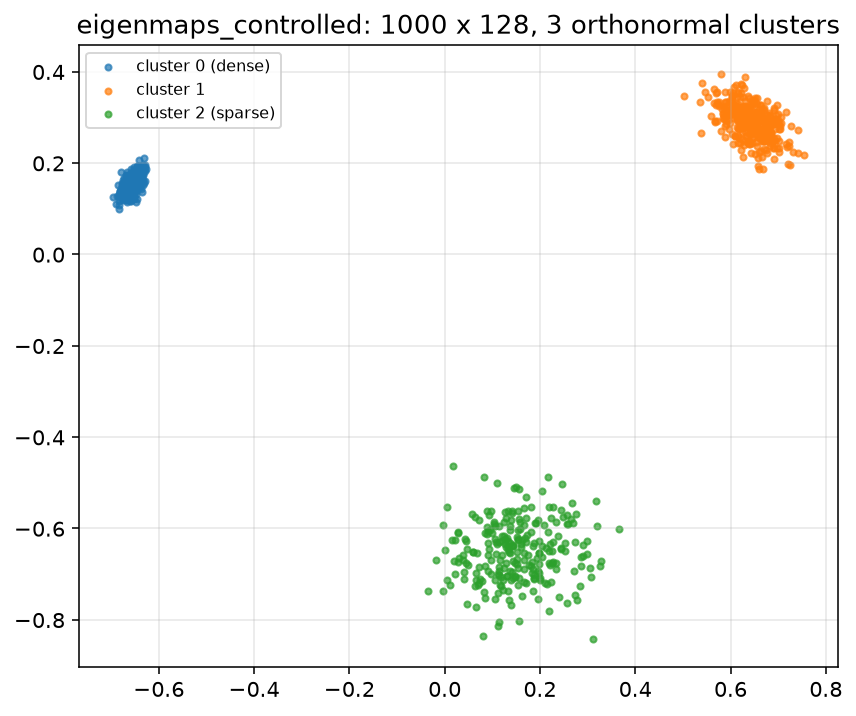

items: (1000, 128)  counts: [400, 350, 250]
cross-cluster cosine ~ -0.0022


In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder, sequence_by_lambda, sequence_by_graph

SEED = 42
DATA_PATH = Path("../dataset/eigenmaps_controlled.parquet")

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

# The dataset README prescribes these graph parameters; the pre-0.28 defaults
# (eps=0.001) disconnect the unit-norm feature graph (every lambda ~ 0).
# Notably, 0.28.0's recalibrated defaults (eps=0.5, k=12) match this prescription.
# Reuse only, never regenerate.
GRAPH_PARAMS = {"eps": 0.5, "k": 12, "topk": 8, "p": 2.0, "sigma": 0.5}

X = np.ascontiguousarray(  # pyarrow/pandas slices may be non-contiguous; ArrowSpace asks for C-contiguous rows
    pq.read_table(DATA_PATH).to_pandas().to_numpy(np.float64)
)
N, D = X.shape
assert X.shape == (1000, 128) and np.allclose(np.linalg.norm(X, axis=1), 1.0)

# Ground truth: three orthonormal clusters. The shipped copy drops the `cluster`
# column; recover it from the data — the clusters are mutually orthogonal, so
# k-means (fixed seed) recovers them exactly. K-means labels are index-arbitrary, so
# we re-index clusters by mean effective-dimension count (dense -> sparse). This makes
# "cluster 2" always the sparsest, so later narrative/asserts about labels==2 are correct.
p2 = X ** 2
eff_dims = p2.sum(axis=1) ** 2 / np.sum(p2 ** 2, axis=1)   # participation ratio per item
_km = KMeans(3, n_init=10, random_state=SEED).fit_predict(X)
_dense_first = np.argsort([-eff_dims[_km == c].mean() for c in range(3)])
labels = np.empty_like(_km)
for _new, _old in enumerate(_dense_first):
    labels[_km == _old] = _new
NAMES = ["cluster 0 (dense)", "cluster 1", "cluster 2 (sparse)"]
COLORS = np.asarray(plt.get_cmap("tab10").colors)

def modal_share(ix):
    """Fraction of a motif's items belonging to one k-means cluster."""
    _, cnt = np.unique(labels[list(ix)], return_counts=True)
    return float(cnt.max() / len(ix))

xy = PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, ax = plt.subplots(figsize=(6, 5))
for c in range(3):
    ax.scatter(xy[labels == c, 0], xy[labels == c, 1], s=10, alpha=0.7,
               color=COLORS[c], label=NAMES[c])
ax.legend(fontsize=8)
ax.set_title("eigenmaps_controlled: 1000 x 128, 3 orthonormal clusters")
OUT = Path("output__motives")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
fig.savefig(OUT / "fig_01_dataset.png")
plt.show()

print(f"items: {X.shape}  counts: {np.bincount(labels).tolist()}")
print(f"cross-cluster cosine ~ {(X @ X.T)[labels[:, None] != labels[None, :]].mean():.4f}")

## 1 · EigenMaps motifs: feature space *and* item space

Two entry points since 0.28. `spot_motives_eigen` runs directly on the $128\times128$
$L_F$ and returns groups of *dimensions* (the node space is now documented — #165).
`spot_motives_eigen_items` mirrors the energy track: it rebuilds the X×X centroid
graph from the index's own rows, detects motifs there, and expands them through the
item→cluster assignments to **item indices** — every motif a union of whole
clusters, ids guaranteed in `0..n_items`.

In [2]:
aspace, gl = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_dims_reduction(False, None)
    .build(GRAPH_PARAMS, X)
)
lam = np.asarray(aspace.lambdas())
print(f"nitems={aspace.nitems}  L_F={gl.shape()}  degenerate lambdas: "
      f"{int(np.sum(np.abs(lam) < 1e-12))} / {len(lam)}")

motifs_default = aspace.spot_motives_eigen(gl, None)
print(f"feature-space, default cfg -> motifs: {len(motifs_default)}, sizes: "
      f"{sorted((len(m) for m in motifs_default), reverse=True)[:8]}")
assert max(max(m) for m in motifs_default) < D, "feature-space ids live in 0..F-1"

MOTIVE_CFG = {"top_l": 8, "min_triangles": 2, "min_clust": 0.3,
              "max_motif_size": 24, "max_sets": 64, "jaccard_dedup": 0.7}
motifs = aspace.spot_motives_eigen(gl, MOTIVE_CFG)
sizes = sorted((len(m) for m in motifs), reverse=True)
print(f"feature-space, tuned cfg -> motifs: {len(motifs)}, sizes head: {sizes[:10]}")
assert len(motifs_default) >= 5, "a 128-node graph should triangulate into multiple motifs"

eigen_item_motifs = aspace.spot_motives_eigen_items(gl, None)
eigen_item_motifs.sort(key=lambda m: -len(m))
for i, m in enumerate(eigen_item_motifs):
    print(f"  item-space m{i}: items={len(m):4d}  modal-cluster share={modal_share(m):.2f}")
assert all(0 <= i < N for m in eigen_item_motifs for i in m), "item ids in 0..n_items"
assert len(eigen_item_motifs) >= 2, "the centroid graph should yield whole-cluster motifs"

nitems=1000  L_F=(128, 128)  degenerate lambdas: 1 / 1000
feature-space, default cfg -> motifs: 10, sizes: [32, 32, 32, 32, 32, 32, 32, 32]
feature-space, tuned cfg -> motifs: 11, sizes head: [24, 24, 24, 24, 24, 24, 24, 24, 24, 24]
  item-space m0: items= 350  modal-cluster share=1.00
  item-space m1: items= 250  modal-cluster share=1.00


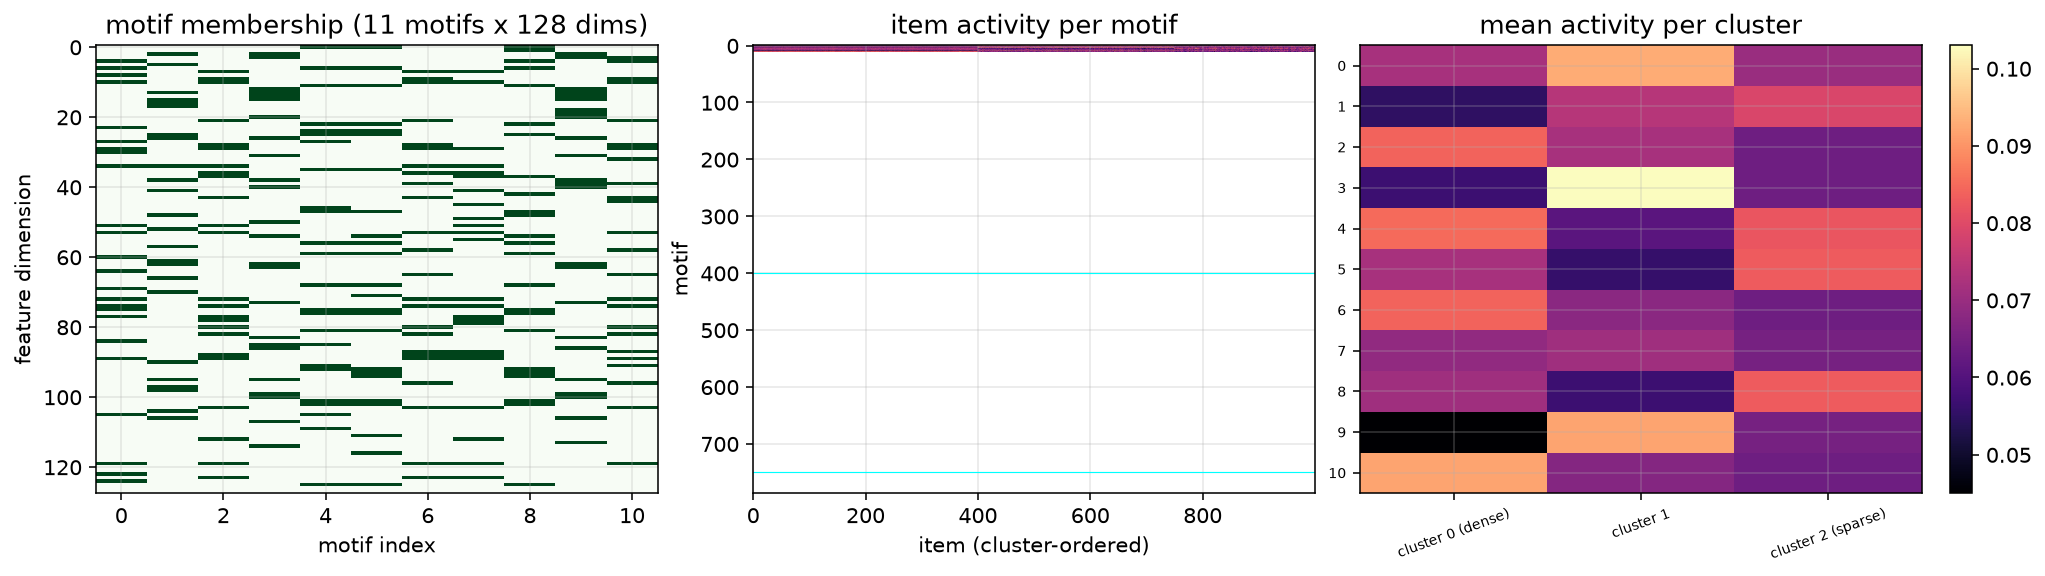

 motif  size  activity c0  activity c1  activity c2  max/min ratio
     0    24        0.072        0.093        0.070           1.33
     1    24        0.055        0.074        0.079           1.44
     2    24        0.084        0.072        0.064           1.32
     3    24        0.057        0.103        0.064           1.80
     4    24        0.085        0.061        0.082           1.39
     5    24        0.072        0.056        0.083           1.49
     6    24        0.084        0.068        0.064           1.32
     7    24        0.069        0.071        0.065           1.08


In [3]:
# Validate motifs against the item side: mean |value| over the motif's dimensions.
A = np.abs(X)
act = np.stack([A[:, m].mean(axis=1) for m in motifs])          # (n_motifs, n_items)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))
grid = np.zeros((D, len(motifs)))
for j, m in enumerate(motifs):
    grid[m, j] = 1
axes[0].imshow(grid, cmap="Greens", aspect="auto")
axes[0].set_xlabel("motif index"); axes[0].set_ylabel("feature dimension")
axes[0].set_title(f"motif membership ({len(motifs)} motifs x {D} dims)")

axes[1].imshow(act, aspect="auto", cmap="magma")
axes[1].set_xlabel("item (cluster-ordered)"); axes[1].set_ylabel("motif")
axes[1].set_title("item activity per motif")
for y in np.cumsum(np.bincount(labels))[:-1] - 0.5:
    axes[1].axhline(y, color="cyan", lw=0.6)

rows = []
for j, m in enumerate(motifs[:16]):
    a_row = act[j]
    mus = [float(a_row[labels == c].mean()) for c in range(3)]
    rows.append({"motif": j, "size": len(m),
                 **{f"activity c{c}": round(v, 3) for c, v in enumerate(mus)},
                 "max/min ratio": round(max(mus) / (min(mus) + 1e-9), 2)})
df_mot = pd.DataFrame(rows)
im = axes[2].imshow(df_mot[[f"activity c{c}" for c in range(3)]].to_numpy(),
                    aspect="auto", cmap="magma")
axes[2].set_xticks(range(3), NAMES, fontsize=7, rotation=20)
axes[2].set_yticks(df_mot["motif"], df_mot["motif"], fontsize=7)
axes[2].set_title("mean activity per cluster")
fig.colorbar(im, ax=axes[2], fraction=0.046)
fig.savefig(OUT / "fig_02_eigen_motifs.png")
plt.show()
print(df_mot.head(8).to_string(index=False))

**Reading.** Motifs are **hypotheses about the wiring of $L_F$**, not claims about
semantics. Two families show up on this dataset: broad ensembles whose member dimensions
are active for everyone (shared-support structure), and narrower ensembles with visible
per-cluster activity ratios (mid-column contrast) — those are the interesting ones and are
candidates for cluster-support signatures. The activity panel is where a motif earns or
loses its interpretation.

## 2 · The energy APIs refuse EigenMaps builds (#35)

Before 0.27.3, `spot_motives_energy` on an EigenMaps build silently returned $F\times F$
node ids as if they were item indices — a namespace bug. Now the typed
`ArrowSpaceError::EnergyModeRequired` surfaces across the FFI as a catchable `ValueError`.

The mirror image used to be true as well: `spot_motives_eigen` returned feature ids with
no item-space option on the eigen track — filed as
[arrowspace-rs #165](https://github.com/tuned-org-uk/arrowspace-rs/issues/165) from this
very notebook series, and **resolved in 0.27.4/0.28.0**: `spot_motives_eigen_items` now
provides the item-space contract, the feature-space method documents its node space, and
feature-space detection is deterministic. The tracks also police each other now — calling
the eigen item-space variant on an *energy* build raises the symmetric `ValueError`.

In [4]:
for name in ("spot_motives_energy", "spot_subg_motives"):
    try:
        getattr(aspace, name)(gl, None)
    except ValueError as e:
        print(f"{name} on EigenMaps -> ValueError: {str(e)[:72]}...")

try:
    aspace.spot_motives_eigen(gl, {"top_k": 8})       # typo'd knob
except TypeError as e:
    print(f"unknown cfg key -> TypeError: {str(e)[:72]}...")


spot_motives_energy on EigenMaps -> ValueError: energy mode required: missing energy build (use EnergyMapsBuilder::build...
spot_subg_motives on EigenMaps -> ValueError: energy mode required: missing energy build (use EnergyMapsBuilder::build...


## 3 · EnergyMaps build — where item-level motifs live

Subcentroid granularity drives everything: the default clustering collapses this dataset
to a handful of centroids (below $F$), and every motif swallows the corpus. Force the
splitter past $F$ with `with_cluster_radius` / `with_cluster_max_clusters` — then
`try_spot_motives_energy` rebuilds the motif graph **in subcentroid space** and projects
through `centroid_map`, so the returned indices are genuine item indices.

In [5]:
ENERGY_PARAMS = {
    "eta": 0.06, "steps": 6, "trim_quantile": 0.0, "split_quantile": 0.9,
    "neighbor_k": 6, "split_tau": 0.12,
    "w_lambda": 1.0, "w_disp": 0.5, "w_dirichlet": 0.25,
    "candidate_m": 32, "optical_tokens": None,
}
aspace_e, gl_e = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_cluster_radius(0.02)
    .with_cluster_max_clusters(600)
    .build_energy(X, ENERGY_PARAMS, GRAPH_PARAMS)
)
print(f"energy build: nitems={aspace_e.nitems}  subcentroids={aspace_e.nclusters}  "
      f"gl_e={gl_e.shape()} (bootstrap F x F)")
assert aspace_e.nclusters > D, "subcentroid graph must exceed F for item-space motifs"
# (0.28.0 note: at max_clusters=300 the corrected subcentroid coordinates fuse into one
#  corpus-sized motif; 600 splits fine enough for basin-resolved item motifs.)

with_spectral is an experimental feature, results may be unprecise. Keep the default to false


energy build: nitems=1000  subcentroids=600  gl_e=(128, 128) (bootstrap F x F)


## 4 · `spot_motives_energy` — motifs in *item* space

item motifs: 8
  m0: items=253  modal-cluster share=0.57
  m1: items=115  modal-cluster share=0.97
  m2: items=106  modal-cluster share=0.91
  m3: items= 75  modal-cluster share=0.80
  m4: items= 59  modal-cluster share=0.95
  m5: items= 54  modal-cluster share=1.00
  m6: items= 54  modal-cluster share=1.00
  m7: items= 52  modal-cluster share=1.00


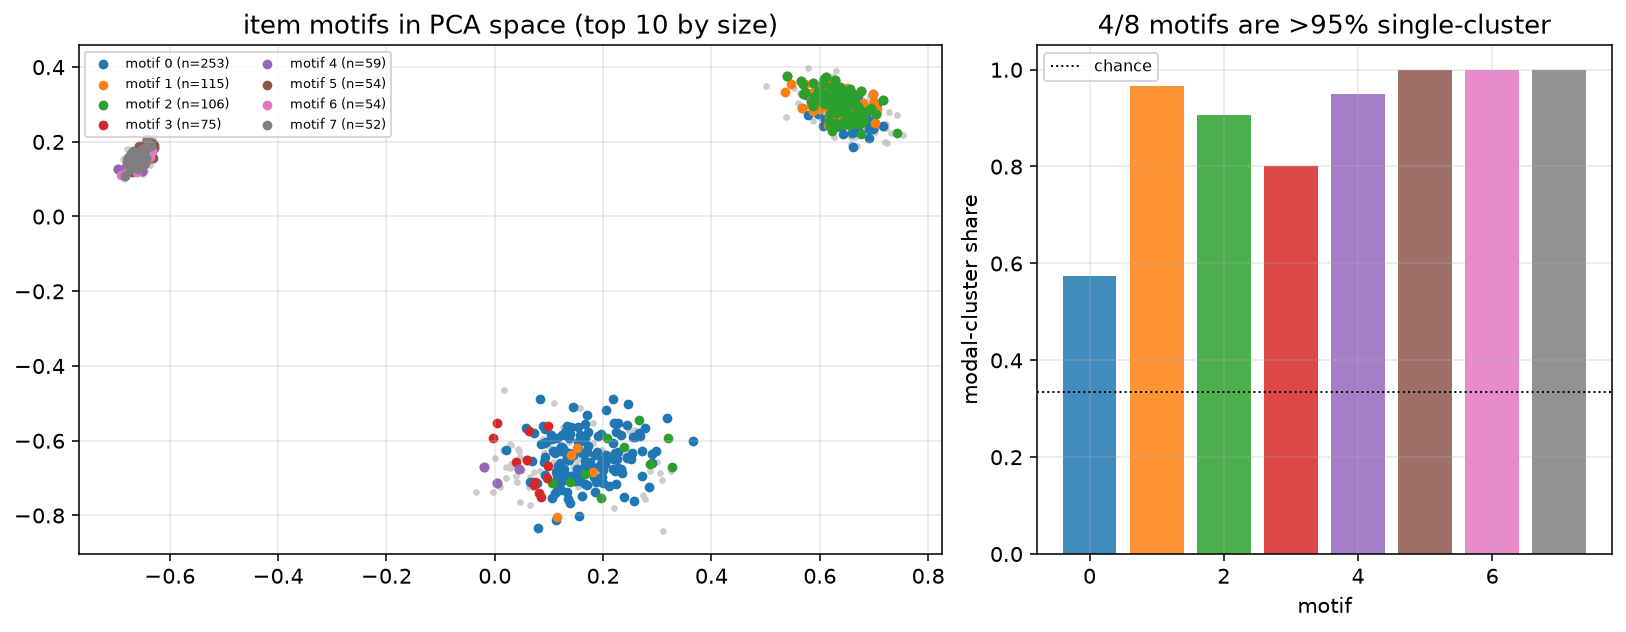

In [6]:
MOTIVE_CFG_E = {"top_l": 8, "min_triangles": 1, "min_clust": 0.0,
                "max_motif_size": 60, "max_sets": 48, "jaccard_dedup": 0.4}
item_motifs = aspace_e.spot_motives_energy(gl_e, MOTIVE_CFG_E)
item_motifs.sort(key=lambda m: -len(m))

def modal_share(ix):
    _, cnt = np.unique(labels[list(ix)], return_counts=True)
    return float(cnt.max() / len(ix))

print(f"item motifs: {len(item_motifs)}")
for i, m in enumerate(item_motifs[:10]):
    print(f"  m{i}: items={len(m):3d}  modal-cluster share={modal_share(m):.2f}")

n_pure = sum(1 for m in item_motifs if modal_share(m) > 0.95)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"width_ratios": [3, 2]})
ax = axes[0]
ax.scatter(xy[:, 0], xy[:, 1], s=6, c="#cccccc")
for i, m in enumerate(item_motifs[:10]):
    ax.scatter(xy[m, 0], xy[m, 1], s=16, color=COLORS[i % 10], label=f"motif {i} (n={len(m)})")
ax.legend(fontsize=6.5, loc="best", ncols=2)
ax.set_title("item motifs in PCA space (top 10 by size)")

ax = axes[1]
ax.bar(range(len(item_motifs)), [modal_share(m) for m in item_motifs],
       color=[COLORS[i % 10] for i in range(len(item_motifs))], alpha=0.85)
ax.axhline(1 / 3, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel("motif"); ax.set_ylabel("modal-cluster share")
ax.set_title(f"{n_pure}/{len(item_motifs)} motifs are >95% single-cluster")
ax.legend(fontsize=8)
fig.savefig(OUT / "fig_03_item_motifs.png")
plt.show()
assert len(item_motifs) >= 5 and n_pure >= 3, "granularity tuning should produce pure item motifs"

**Reading.** Compare the two item-space tracks on the same data: the eigen track returned
two whole-cluster unions (350 + 250 items, purity 1.0 each — cluster granularity), while
the energy track resolves *sub-cluster* structure: several motifs are >95% single-cluster
at sizes the eigen track cannot express, and the largest is a multi-basin union whose size
tracks how much inter-basin wiring survived top-$L$ pruning. Same detector, two
resolutions — pick the track that matches the question.

## 5 · `spot_subg_motives` — subgraph dicts with optional Rayleigh cohesion

Same detection pass, dict output. `rayleigh_max` **doubles as the switch that populates
the `"rayleigh"` field** — left unset the field is `None` (#35 finding 2), which reads like
missing data but is really "not computed".

rayleigh_max=None: 8 subgs; rayleigh populated on 0/8; range [nan, nan]
rayleigh_max=0.1: 8 subgs; rayleigh populated on 8/8; range [-5.2e-17, 1e-16]


 nodes  items      rayleigh  modal_share  nfeatures  x_dim
    60    253  1.040834e-16     0.573123        128     60
    55    115  4.683753e-17     0.965217        128     55
    56    106 -2.862294e-17     0.905660        128     56
    60     75 -5.204170e-17     0.800000        128     60
    56     59 -4.076600e-17     0.949153        128     56
    54     54 -3.209238e-17     1.000000        128     54
    54     54 -2.255141e-17     1.000000        128     54
    52     52 -4.250073e-17     1.000000        128     52


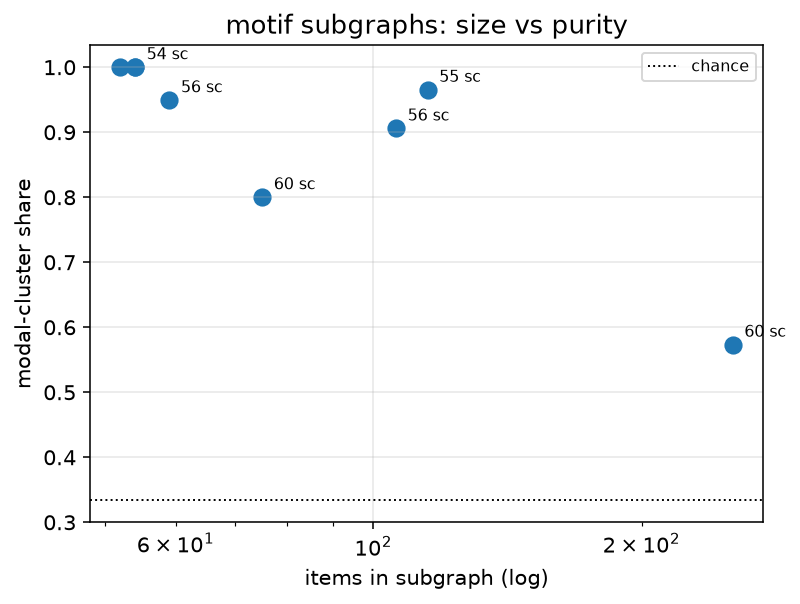

In [7]:
for tag, rmax in (("rayleigh_max=None", None), ("rayleigh_max=0.1", 0.1)):
    sgs = aspace_e.spot_subg_motives(gl_e, {**MOTIVE_CFG_E, "min_size": 3, "rayleigh_max": rmax})
    fields = [s["rayleigh"] for s in sgs]
    n_with = sum(f is not None for f in fields)
    lo = min((f for f in fields if f is not None), default=float("nan"))
    hi = max((f for f in fields if f is not None), default=float("nan"))
    print(f"{tag}: {len(sgs)} subgs; rayleigh populated on {n_with}/{len(sgs)}; range [{lo:.2g}, {hi:.2g}]")

subgs = aspace_e.spot_subg_motives(gl_e, {**MOTIVE_CFG_E, "min_size": 3, "rayleigh_max": 0.1})
rows = [{"nodes": len(s["node_indices"]),
         "items": len(s["item_indices"] or []),
         "rayleigh": s["rayleigh"],
         "modal_share": modal_share(s["item_indices"]) if s["item_indices"] else np.nan,
         "nfeatures": s["nfeatures"], "x_dim": s["x_dim"]}
        for s in sorted(subgs, key=lambda x: -len(x["item_indices"] or []))]
df_sub = pd.DataFrame(rows)
print(df_sub.head(8).to_string(index=False))

fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.scatter(df_sub["items"], df_sub["modal_share"], s=70, c="tab:blue")
for _, r in df_sub.head(6).iterrows():
    ax.annotate(f"{int(r['nodes'])} sc", (r["items"], r["modal_share"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.axhline(1 / 3, color="k", ls=":", lw=1, label="chance")
ax.set_xscale("log"); ax.set_xlabel("items in subgraph (log)"); ax.set_ylabel("modal-cluster share")
ax.set_title("motif subgraphs: size vs purity")
ax.legend(fontsize=8)
fig.savefig(OUT / "fig_04_subg_cohesion.png")
plt.show()

Every retained set has $|R_L(1_S)| \le 1.1\times10^{-16}$: **zero-cut** at floating-point
precision — exactly what "cohesive subgraph" means spectrally. The $0.1$ threshold is far
from binding at this scale; it exists to *reject* rough sets on coarser wirings. `x_dim`
counts the subcentroids in the set; `nfeatures` is the feature-space dimension.

## 6 · `spot_subg_centroids` — the centroid hierarchy

centroid-level subgraphs: 3
  level 0: nnodes= 722  roots cover  1000 item slots
  level 1: nnodes=  12  roots cover  1000 item slots
  level 2: nnodes=  12  roots cover  1000 item slots


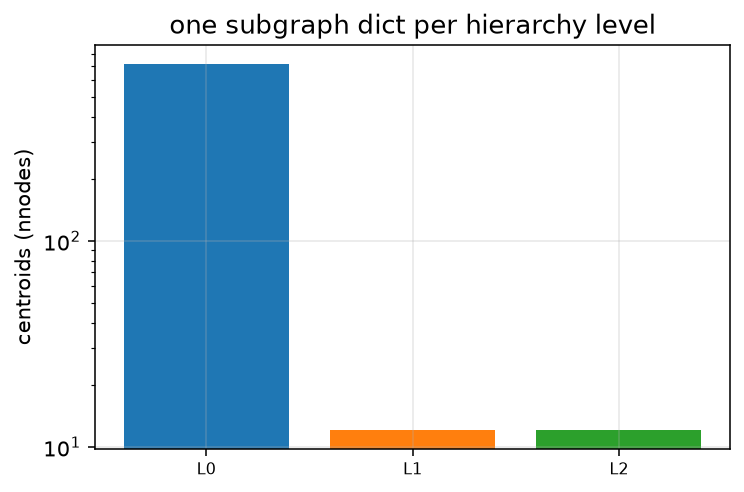

In [8]:
CENTROID_CFG = {"eps": 0.5, "k": 12, "topk": 4, "p": 2.0, "sigma": 0.5,
                "normalise": True, "min_centroids": 2, "max_depth": 3, "seed": SEED}
cent = aspace_e.spot_subg_centroids(gl_e, CENTROID_CFG)
print(f"centroid-level subgraphs: {len(cent)}")
for c in cent:
    covered = sum(len(r) for r in c["root_indices"])
    print(f"  level {c['level']}: nnodes={c['nnodes']:4d}  roots cover {covered:5d} item slots")

levels = sorted({c["level"] for c in cent})
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.bar(range(len(cent)), [c["nnodes"] for c in cent],
       color=COLORS[[c["level"] for c in cent]])
ax.set_xticks(range(len(cent)), [f"L{c['level']}" for c in cent], fontsize=8)
ax.set_yscale("log"); ax.set_ylabel("centroids (nnodes)")
ax.set_title("one subgraph dict per hierarchy level")
fig.savefig(OUT / "fig_05_centroid_levels.png")
plt.show()

## 7 · Energy-mode search contracts

Energy indexes swap the query-side API: `search_energy(q, gl, k)` replaces the $\tau$-blended
search, `search_batch` is refused (`NotImplementedError`, #123), and
`search_linear_sorted` works on both pipelines.

In [9]:
q = X[5]
print("search_energy top-3 (energy):", aspace_e.search_energy(q, gl_e, 3))

try:
    aspace_e.search_batch(X[:4], gl_e, 0.7)
except NotImplementedError as e:
    print("search_batch on energy build -> NotImplementedError:", str(e)[:62], "...")

print("search_linear_sorted top-3:", aspace_e.search_linear_sorted(q, gl_e, 3))

# Pipeline policing is symmetric: the eigen item-space variant refuses energy builds too.
try:
    aspace_e.spot_motives_eigen_items(gl_e, None)
except ValueError as e:
    print(f"eigen item-motifs on EnergyMaps -> ValueError: {str(e)[:60]}...")

search_energy top-3 (energy): [(5, 9.999998606957662e-19), (6, 0.0005179379617666069), (334, 0.0008370523463163138)]
search_batch on energy build -> NotImplementedError: search_batch is not implemented for energy/subcentroid indexes ...
search_linear_sorted top-3: [(308, 0.16084865587910852), (514, 0.16091153008270337), (717, 0.16091153008270337)]
eigen item-motifs on EnergyMaps -> ValueError: eigen mode required: missing eigen build (use ArrowSpaceBuil...


## 8 · Summary

In [10]:
df_sum = pd.DataFrame({
    "pipeline": ["eigen", "eigen", "eigen", "energy", "energy", "energy", "energy"],
    "quantity": ["eigen dimension motifs (default cfg)",
                 "eigen dimension motifs (tuned cfg)",
                 "eigen item-space motifs (whole-cluster unions)",
                 "subcentroids in energy build",
                 "energy item motifs",
                 "pure energy item motifs (>95% single cluster)",
                 "subgraph dicts with Rayleigh computed"],
    "value": [len(motifs_default), len(motifs), len(eigen_item_motifs),
              aspace_e.nclusters, len(item_motifs), n_pure, len(subgs)],
})
df_sum.to_csv(OUT / "motives_summary.csv", index=False)
df_sub.to_csv(OUT / "subg_table.csv", index=False)
print(df_sum.to_string(index=False))

pipeline                                       quantity  value
   eigen           eigen dimension motifs (default cfg)     10
   eigen             eigen dimension motifs (tuned cfg)     11
   eigen eigen item-space motifs (whole-cluster unions)      2
  energy                   subcentroids in energy build    600
  energy                             energy item motifs      8
  energy  pure energy item motifs (>95% single cluster)      4
  energy          subgraph dicts with Rayleigh computed      8


**Reading.**

1. **Node space first, config second.** The eigen track now offers *both* namespaces —
   `spot_motives_eigen` returns *dimensions*, `spot_motives_eigen_items` returns *items*;
   the energy track returns items at subcentroid resolution. Each call polices its build
   type (`ValueError` on the wrong pipeline, both directions), and misreading the node
   space was the actual historical bug (#35, #165).
2. **Motif granularity is a build parameter.** Item-side motifs only become basin-resolved
   once the energy splitter is forced past $F$ subcentroids; with the default heuristic the
   subcentroid graph is smaller than the feature space and every motif swallows the corpus.
3. **Rayleigh validation is opt-in** (`rayleigh_max` both filters and populates), and the
   retained sets here are zero-cut at float precision — cohesion at its strongest.
4. **128 dims matter, and so does the version.** At $D=128$ the $L_F$ triangle-detector
   returns a genuinely partitioned motif family; on toy $D$-dimensional data it degenerates
   to one set. And 0.28.0's #167 layout fix changed the graph content itself — motif counts
   from $\le$ 0.27.4 builds are not comparable, and feature-space detection is only
   deterministic since #165's fix.

**Caveats.** Modal-cluster purity is a yardstick for this controlled fixture only — on real
embeddings, validate motifs with held-out probes (ablation of a motif's items against its
own members' retrieval). All numbers here are single-seed; sweep `SEED` before trusting
motif counts quantitatively.

### References
- arrowspace-rs `analysis::motives` (triangle seeding + greedy expansion + Jaccard dedup)
- pyarrowspace #35 (energy-mode enforcement, Rayleigh opt-in, unknown-key errors)
- arrowspace-rs #165 (item-space motifs for the EigenMaps track — resolved in 0.28,
  `spot_motives_eigen_items` + documented node spaces)
- `notebooks/README.md` principles — API scores only, $\lambda$ as a final score.